# 03 · Survival analysis: how long until a matching flat comes up?
**Owner:** Pricing & Availability Lead · **Needs:** step 1b done; `lifelines` (Terminal → Run Task → *Install modelling libraries*)

**Question.** For a given block and flat type, how many months pass between one resale and the next?
That tells a buyer how readily flats like the one they want come onto the market.

| Design choice | Decision | Why |
|---|---|---|
| Unit | block × flat type (e.g. 4-room flats in Blk 406 AMK Ave 10) | The resale data has no unit numbers, but block + flat type is consistent |
| Event | a resale of that flat type in that block | Directly observed in HDB data (no scraping needed) |
| Duration | months between successive sales; same-month repeat = 0.5 months | Data is monthly |
| Right-censoring | the last spell runs to Sep 2026 with no sale yet | Standard; KM and Cox handle it |
| Never-sold groups | **included** as censored spells | Leaving them out would make waits look far shorter than they are |
| Before the first sale (old blocks) | dropped | The previous sale happened before 2017, so the spell's start is unknown |
| Newer blocks | clock starts when they become eligible (completion year + 5 for MOP) | Their first-ever resale wait is observable |

Sections 1–6 build the data and a first model; sections 7–9 add location, fix the proportional-hazards problem, and produce `outputs/expected_wait.csv` for the recommender.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "../src")
import config as C
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import concordance_index

TYPES = ["2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE"]
COL = dict(zip(TYPES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "axes.axisbelow": True, "legend.frameon": False})

def month_index(m):                       # "2017-01" -> integer months, so gaps are simple subtraction
    return m.str[:4].astype(int) * 12 + m.str[5:7].astype(int) - 1

df = pd.read_csv(C.RESALE_CLEAN, dtype={"block": str})
df = df[df["in_scope"] & df["flat_type"].isin(TYPES)].copy()
df["t"] = month_index(df["month"])
T0, T_END = df["t"].min(), df["t"].max()                 # Jan 2017 .. last complete month
print(f"{len(df):,} sales, window {df['month'].min()} to {df['month'].max()} ({T_END - T0 + 1} months)")

241,407 sales, window 2017-01 to 2026-09 (117 months)


## 1 · Exposure: how many flats of each type are in each block
From HDB Property Information. A block with 200 four-room flats should see more sales than one with 20, so this is the key control.

In [2]:
p = pd.read_csv(C.PROPINFO, dtype={"blk_no": str})
p = p[p["residential"] == "Y"].copy()
p["address"] = (p["blk_no"].str.strip().str.upper() + " "
                + p["street"].str.strip().str.upper().str.replace(r"\s+", " ", regex=True))
cols = {"2room_sold": "2 ROOM", "3room_sold": "3 ROOM", "4room_sold": "4 ROOM", "5room_sold": "5 ROOM", "exec_sold": "EXECUTIVE"}
stock = (p.melt(id_vars=["address", "year_completed", "max_floor_lvl", "bldg_contract_town"],
                value_vars=list(cols), var_name="col", value_name="units")
           .query("units > 0").assign(flat_type=lambda d: d["col"].map(cols)).drop(columns="col"))
# A block becomes resellable after the 5-year MOP; we only know the completion year, so assume mid-year
stock["t_eligible"] = (stock["year_completed"] + 5) * 12 + 6
print(f"{len(stock):,} block x flat-type groups with sold units")

19,966 block x flat-type groups with sold units


## 2 · Build the spells
One row per waiting spell: `duration` (months), `event` (1 = ended in a sale, 0 = still waiting at Sep 2026).

In [3]:
def build_spells(sales, stock, t0, t_end):
    rows = []
    sales_by_group = sales.groupby(["address", "flat_type"])["t"].apply(lambda s: np.sort(s.to_numpy()))
    for g in stock.itertuples():
        times = sales_by_group.get((g.address, g.flat_type), np.array([], dtype=int))
        old = g.t_eligible <= t0                                   # resellable before the data starts
        start = None if old else g.t_eligible                      # new blocks: clock starts at eligibility
        if old and len(times) == 0:
            start = t0                                             # never sold in the whole window
        for t in times:
            if start is not None and t >= start:
                rows.append((g.address, g.flat_type, start, max(t - start, 0.5), 1))
            start = t                                              # next spell starts at this sale
        if start is not None and start <= t_end:
            rows.append((g.address, g.flat_type, start, max(t_end - start, 0.5), 0))   # still waiting
    return pd.DataFrame(rows, columns=["address", "flat_type", "t_start", "duration", "event"])

spells = build_spells(df, stock, T0, T_END)
spells = spells.merge(stock[["address", "flat_type", "units", "year_completed", "max_floor_lvl", "bldg_contract_town"]],
                      on=["address", "flat_type"], how="left")
spells["start_year"] = spells["t_start"] // 12
spells.to_csv(C.PROCESSED / "survival_spells.csv", index=False)
print(f"{len(spells):,} spells · {spells['event'].mean():.1%} end in a sale · "
      f"{(spells['event'] == 0).sum():,} censored -> data/processed/survival_spells.csv")

244,924 spells · 92.5% end in a sale · 18,457 censored -> data/processed/survival_spells.csv


## 3 · Sanity checks

In [4]:
print(spells.groupby("flat_type").agg(spells=("event", "size"), events=("event", "sum"),
                                       median_duration=("duration", "median")).loc[TYPES].to_string())
missing = set(map(tuple, df[["address", "flat_type"]].drop_duplicates().values)) - set(map(tuple, stock[["address", "flat_type"]].values))
print(f"\nGroups with sales but missing from HDB Property Information: {len(missing)} (dropped)")
never = spells.groupby(["address", "flat_type"])["event"].sum().eq(0).sum()
print(f"Groups that never sold in the window (fully censored): {never:,}")

           spells  events  median_duration
flat_type                                 
2 ROOM       5440    4883              3.0
3 ROOM      57905   54694              3.0
4 ROOM     103881   96323              3.0
5 ROOM      60180   54755              4.0
EXECUTIVE   17518   15812              5.0

Groups with sales but missing from HDB Property Information: 3 (dropped)
Groups that never sold in the window (fully censored): 2,351


**Finding:** _spell counts, censoring share, anything odd._

## 4 · Kaplan–Meier: waiting-time curves by flat type
The curve shows the share of blocks still waiting for their next sale after *t* months.

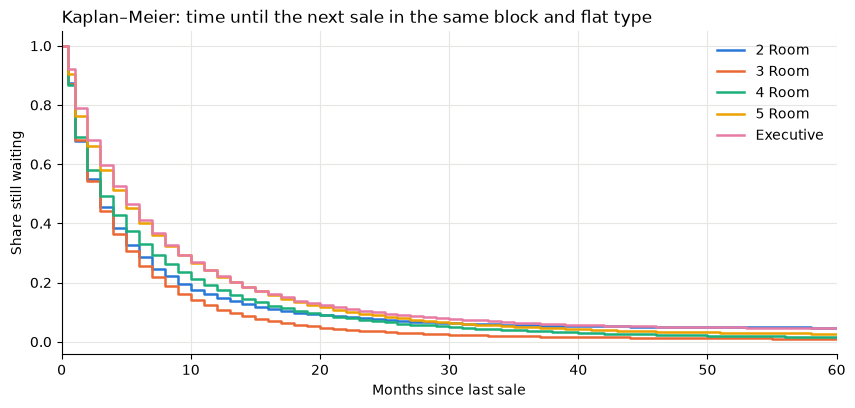

Median months to next sale: {'2 Room': np.float64(3.0), '3 Room': np.float64(3.0), '4 Room': np.float64(3.0), '5 Room': np.float64(5.0), 'Executive': np.float64(5.0)}
Log-rank test across flat types: chi2 = 4,214, p = 0


In [5]:
fig, ax = plt.subplots()
kmf, medians = KaplanMeierFitter(), {}
for t in TYPES:
    d = spells[spells["flat_type"] == t]
    kmf.fit(d["duration"], d["event"], label=t.title())
    kmf.plot_survival_function(ax=ax, ci_show=False, color=COL[t], linewidth=1.8)
    medians[t] = kmf.median_survival_time_
ax.set_xlim(0, 60); ax.set_xlabel("Months since last sale"); ax.set_ylabel("Share still waiting")
ax.set_title("Kaplan–Meier: time until the next sale in the same block and flat type", loc="left")
plt.show()
print("Median months to next sale:", {k.title(): round(v, 1) for k, v in medians.items()})
res = multivariate_logrank_test(spells["duration"], spells["flat_type"], spells["event"])
print(f"Log-rank test across flat types: chi2 = {res.test_statistic:,.0f}, p = {res.p_value:.2g}")

**Finding:** _which flat types turn over fastest; are the differences significant?_

## 5 · Exposure matters: KM by number of units of that type in the block

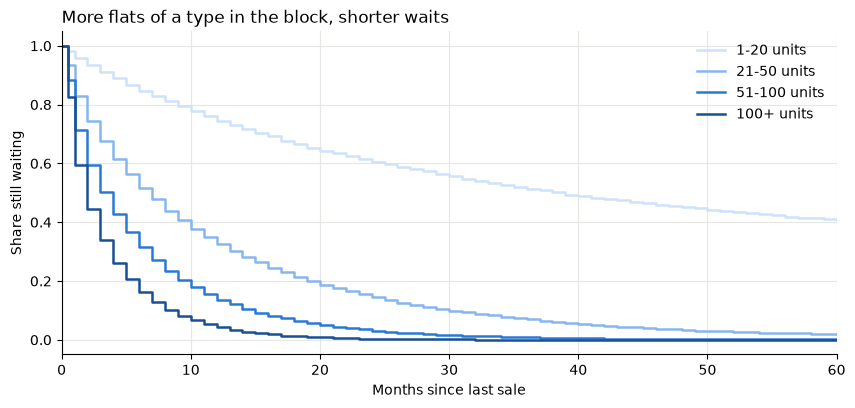

In [6]:
spells["units_band"] = pd.cut(spells["units"], [0, 20, 50, 100, 1e4], labels=["1-20", "21-50", "51-100", "100+"])
fig, ax = plt.subplots()
for band, c in zip(["1-20", "21-50", "51-100", "100+"], ["#cde2fb", "#86b6ef", "#2a78d6", "#184f95"]):
    d = spells[spells["units_band"] == band]
    kmf.fit(d["duration"], d["event"], label=f"{band} units")
    kmf.plot_survival_function(ax=ax, ci_show=False, color=c, linewidth=1.8)
ax.set_xlim(0, 60); ax.set_xlabel("Months since last sale"); ax.set_ylabel("Share still waiting")
ax.set_title("More flats of a type in the block, shorter waits", loc="left"); plt.show()

**Finding:** _how strongly block size drives waits. This is why `log(units)` must be in the Cox model._

## 6 · Cox proportional hazards (starter, no location yet)
Hazard ratio > 1 = sales happen faster. Covariates available now: flat type, region, log units (exposure), block age at spell
start, block height, and the market period (a 'from 2020' indicator for the boom years). Standard errors are clustered by block,
because spells from the same block are not independent.

Validation, as in the proposal: fit on spells **starting before 2023**, then score the C-index on spells starting 2023+.

_Runtime: about 5–6 minutes (clustered standard errors on ~146k spells). Let it run._

In [7]:
region_of = {t: r for r, ts in C.REGIONS.items() for t in ts}
# Never-sold blocks have no resale rows, so take town from HDB's building-contract-town code.
# The code -> town mapping is learned from blocks that appear in both datasets.
known = stock[["address", "bldg_contract_town"]].drop_duplicates().merge(df[["address", "town"]].drop_duplicates(), on="address")
code_town = known.groupby("bldg_contract_town")["town"].agg(lambda s: s.mode()[0])
X = spells.copy()
X["region"] = X["bldg_contract_town"].map(code_town).map(region_of)
print(f"Region found for {X['region'].notna().mean():.2%} of spells; the rest are dropped from the Cox model")
X = X[X["region"].notna()]
X["log_units"] = np.log(X["units"])
X["block_age"] = X["start_year"] - X["year_completed"]
# Market period: one 'from 2020' indicator (the boom). Finer periods can't be validated on a time split,
# because the test years would get a period the model never saw.
X["from_2020"] = (X["start_year"] >= 2020).astype(float)
design = pd.get_dummies(X[["flat_type", "region"]], drop_first=True, dtype=float)
design[["log_units", "block_age", "max_floor_lvl", "from_2020"]] = X[["log_units", "block_age", "max_floor_lvl", "from_2020"]]
design[["duration", "event", "address"]] = X[["duration", "event", "address"]]
design = design.dropna()

train, test = design[X.loc[design.index, "start_year"] < 2023], design[X.loc[design.index, "start_year"] >= 2023]
cph = CoxPHFitter(penalizer=0.01)
cph.fit(train, duration_col="duration", event_col="event", cluster_col="address")
cph.print_summary(decimals=3, columns=["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"])
c_test = concordance_index(test["duration"], -cph.predict_partial_hazard(test), test["event"])
print(f"\nC-index, train (spells starting before 2023): {cph.concordance_index_:.3f} · test (2023+): {c_test:.3f}")

Region found for 100.00% of spells; the rest are dropped from the Cox model


model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
cluster col,'address'
penalizer,0.01
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,146032
number of events observed,143424
partial log-likelihood,-1543952.110



C-index, train (spells starting before 2023): 0.684 · test (2023+): 0.678


**Finding:** _which factors speed up or slow down sales; does the C-index hold up on the later period?_

In [8]:
# Proportional-hazards check on a sample (the full data makes every small deviation 'significant')
cph_s = CoxPHFitter(penalizer=0.01).fit(train.sample(20000, random_state=0).drop(columns="address"),
                                        duration_col="duration", event_col="event")
cph_s.check_assumptions(train.sample(20000, random_state=0).drop(columns="address"), p_value_threshold=0.01, show_plots=False)

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'region_NORTH' failed the non-proportional test: p-value is 0.0031.

   Advice: with so few unique values (only 2), you can include `strata=['region_NORTH', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'region_NORTH-EAST' failed the non-proportional test: p-value is 0.0123.

   Advice: with so few unique values (only 2), you can include `strata=['region_NORTH-EAST', ...]`
in the call in `.fit`. See documentation in link [E] below.

3. Variable 'region_WEST' failed the non-proportional test: p-value is 0.0003.

   Advice: with so few unique values (only 2), you can include `strata=['region_WEST', ...]` in the
call in `.fit`. See documentation in link [E] below.

4. Variable 'block_age' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'block_age' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional

[]

**Finding:** _which covariates violate proportional hazards, and the remedy (stratify on them, e.g. `strata=['from_2020']`, or add a time interaction)._

## 7 · Final model: add location, stratify on block age
Two changes from section 6:
1. **Location covariates** from `block_features.csv`: MRT distance *at the start of the spell* (so new stations count only once open),
   plus hawker centre, park and supermarket distance, and primary schools within 1 km.
2. **Block age violated proportional hazards**, so instead of a covariate it becomes a **stratum**: each age band gets its own
   baseline waiting-time curve, and the other effects are shared across bands. This is the standard remedy.

Blocks that never had a single resale were never geocoded (they have no resale address), so their spells drop out here.
The count is printed below; note it as a limitation.

In [9]:
bf = pd.read_csv(C.PROCESSED / "block_features.csv")
rf = (pd.read_csv(C.PROCESSED / "resale_features.csv", usecols=["address", "month", "dist_mrt_at_sale_m"], low_memory=False)
        .drop_duplicates(["address", "month"]))
F = X.copy()
F["month"] = (F["t_start"] // 12).astype(int).astype(str) + "-" + (F["t_start"] % 12 + 1).astype(int).map("{:02d}".format)
F = F.merge(rf, on=["address", "month"], how="left")
F = F.merge(bf[["address", "dist_mrt_now_m", "dist_hawker_m", "dist_park_m", "dist_supermarket_m", "n_primary_1km"]],
            on="address", how="left")
F["dist_mrt_m"] = F["dist_mrt_at_sale_m"].fillna(F["dist_mrt_now_m"])     # spells not starting at a sale use today's network
before = len(F); F = F.dropna(subset=["dist_mrt_m", "dist_hawker_m", "dist_park_m", "dist_supermarket_m"])
print(f"Dropped {before - len(F):,} spells ({(before - len(F)) / before:.1%}) from blocks with no coordinates (never resold)")

AGE_BANDS = [-1, 15, 30, 45, 200]; AGE_LABELS = ["<15", "15-29", "30-44", "45+"]
def model_frame(F):
    M = pd.get_dummies(F[["flat_type", "region"]], drop_first=True, dtype=float)
    for col in ["dist_mrt_m", "dist_hawker_m", "dist_park_m", "dist_supermarket_m"]:
        M["log_" + col[:-2]] = np.log1p(F[col])            # dist_mrt_m -> log_dist_mrt
    M[["log_units", "max_floor_lvl", "from_2020", "n_primary_1km"]] = F[["log_units", "max_floor_lvl", "from_2020", "n_primary_1km"]].astype(float)
    M["age_band"] = pd.cut(F["block_age"], AGE_BANDS, labels=AGE_LABELS).astype(str)
    return M
M = model_frame(F)
M[["duration", "event", "address"]] = F[["duration", "event", "address"]].to_numpy()
M[["duration", "event"]] = M[["duration", "event"]].astype(float)
print(f"{len(M):,} spells · strata sizes: {M['age_band'].value_counts().to_dict()}")

Dropped 251 spells (0.1%) from blocks with no coordinates (never resold)
244,673 spells · strata sizes: {'30-44': 84708, '<15': 70983, '15-29': 67914, '45+': 21068}


In [10]:
# Validation on a time split (same as section 6), then the final fit on all spells for prediction
tr = M[F["start_year"].to_numpy() < 2023]; te = M[F["start_year"].to_numpy() >= 2023]
cv = CoxPHFitter(penalizer=0.01).fit(tr.drop(columns="address"), "duration", "event", strata=["age_band"])
# With block age as a stratum, its effect lives in the baseline curves, so score with the model's expected wait (which
# includes the stratum) rather than the partial hazard (which ignores it). Higher expected wait = later sale.
def c_index(model, data):
    return concordance_index(data["duration"], model.predict_expectation(data.drop(columns="address")), data["event"])
print(f"C-index · train (before 2023): {c_index(cv, tr):.3f} · test (2023+): {c_index(cv, te):.3f}  (section 6 model: 0.684 / 0.678)")

cph2 = CoxPHFitter(penalizer=0.01).fit(M, "duration", "event", strata=["age_band"], cluster_col="address")
cph2.print_summary(decimals=3, columns=["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"])

C-index · train (before 2023): 0.689 · test (2023+): 0.678  (section 6 model: 0.684 / 0.678)


model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
cluster col,'address'
penalizer,0.01
l1 ratio,0.0
robust variance,True
strata,age_band
baseline estimation,breslow
number of observations,244673
number of events observed,226467


**Finding:** _did location improve the C-index? Which location factors speed up sales (hazard ratio > 1)? For log-distance terms, a ratio below 1 means flats further away sell less often._

## 8 · From blocks to profiles: expected wait for a matching flat
A buyer wants **any** flat in their profile (town × flat type × lease band × MRT band × storey band), not a specific block.

1. For every block × flat type **today** (Sep 2026 covariates), the Cox model gives a survival curve. Its area up to 10 years is the
   expected gap between sales, so the block's sale rate ≈ 1 / gap (sales per month).
2. A block spans several storey bands, so its rate is split by the block's historical share of sales in each band
   (or by its share of floors if it has never sold).
3. Rates of all blocks in a profile add up; **expected wait = 1 / total rate**.

In [11]:
NOW_YEAR = 2026
now = stock.merge(bf[["address", "dist_mrt_now_m", "dist_hawker_m", "dist_park_m", "dist_supermarket_m", "n_primary_1km"]], on="address")
now = now.rename(columns={"dist_mrt_now_m": "dist_mrt_m"})
now["region"] = now["bldg_contract_town"].map(code_town).map(region_of)
now["town"] = df.drop_duplicates("address").set_index("address")["town"].reindex(now["address"]).to_numpy()
now["town"] = now["town"].fillna(now["bldg_contract_town"].map(code_town))
now["log_units"], now["from_2020"] = np.log(now["units"]), 1.0
now["block_age"] = NOW_YEAR - now["year_completed"]
now = now.dropna(subset=["region"]).reset_index(drop=True)
Mn = model_frame(now).reindex(columns=[c for c in M.columns if c not in ("duration", "event", "address")], fill_value=0.0)

times = np.arange(0, 121)                                         # months; area under the curve = expected gap (capped at 10 yrs)
surv = cph2.predict_survival_function(Mn, times=times)
area = getattr(np, "trapezoid", None) or np.trapz                    # name differs across NumPy versions
now["gap_months"] = area(surv.to_numpy(), times, axis=0)
now["rate"] = 1 / now["gap_months"]
print(now["gap_months"].describe().round(1).to_string())

count    18209.0
mean        20.8
std         26.2
min          0.7
25%          6.2
50%          9.9
75%         20.9
max        111.3


In [12]:
# Lease band today and storey-band shares per block
lease_start = df.groupby("address")["lease_commence_date"].agg(lambda s: s.mode()[0])
now["lease_start"] = now["address"].map(lease_start).fillna(now["year_completed"])
now["remaining_lease_now"] = 99 - (NOW_YEAR + 0.75 - now["lease_start"])
band = lambda x, bands: pd.cut(x, [b[0] for b in bands] + [bands[-1][1]], labels=[b[2] for b in bands], right=False).astype(str)
now["lease_band"] = band(now["remaining_lease_now"], C.LEASE_BANDS)
now["mrt_band"] = band(now["dist_mrt_m"], C.MRT_BANDS)

df["storey_band"] = band(df["storey_mid"], C.STOREY_BANDS)
hist = (df.groupby(["address", "flat_type", "storey_band"]).size() / df.groupby(["address", "flat_type"]).size()).rename("share").reset_index()
def floor_shares(max_floor):                                       # never-sold blocks: split by share of floors
    floors = np.arange(1, int(max_floor) + 1)
    s = pd.Series(band(pd.Series(floors, dtype=float), C.STOREY_BANDS)).value_counts(normalize=True)
    return s
fallback = []
for r in now[~now.set_index(["address", "flat_type"]).index.isin(hist.set_index(["address", "flat_type"]).index)].itertuples():
    for sb, sh in floor_shares(r.max_floor_lvl).items():
        fallback.append((r.address, r.flat_type, sb, sh))
shares = pd.concat([hist, pd.DataFrame(fallback, columns=hist.columns)], ignore_index=True)

alloc = now.merge(shares, on=["address", "flat_type"])
alloc["profile_id"] = alloc["town"] + "|" + alloc["flat_type"] + "|" + alloc["lease_band"] + "|" + alloc["mrt_band"] + "|" + alloc["storey_band"]
prof_rate = alloc.assign(r=alloc["rate"] * alloc["share"]).groupby("profile_id")["r"].sum()
profiles = pd.read_csv(C.OUTPUTS / "profiles.csv")
profiles["wait_months"] = (1 / profiles["profile_id"].map(prof_rate)).round(2)
print(f"Profiles with a modelled wait: {profiles['wait_months'].notna().sum():,} / {len(profiles):,}")
gone = profiles[profiles["wait_months"].isna()]
new = set(prof_rate.index) - set(profiles["profile_id"])
print(f"  {len(gone):,} profiles have no flats today: their flats have aged into a lower lease band since they sold "
      f"({int(gone['n_last12'].sum())} sales in the last 12 months, i.e. crossed a band boundary this year)")
print(f"  {len(new):,} profile combinations exist today but have had no sale since 2017 (not in profiles.csv)")
print(profiles["wait_months"].describe(percentiles=[.1, .5, .9]).round(2).to_string())

Profiles with a modelled wait: 1,681 / 1,927
  246 profiles have no flats today: their flats have aged into a lower lease band since they sold (16 sales in the last 12 months, i.e. crossed a band boundary this year)
  147 profile combinations exist today but have had no sale since 2017 (not in profiles.csv)
count    1681.00
mean        5.82
std        14.47
min         0.06
10%         0.28
50%         1.52
90%        14.44
max       221.50


**Finding:** _typical wait for a matching flat; which profiles are scarce (long waits)?_

**Decision for the team:** `profiles.csv` lists every profile that has *ever* sold, with lease band measured at the time of sale. The recommender needs profiles as they exist **today**. Suggest step 4 builds the profile list from current stock (lease band as of now), so prices, waits and shortlists all describe flats a buyer could actually buy.

## 9 · Validate against what actually happened, then hand over
If the model is sensible, profiles it predicts to be quick should be the ones that actually had many sales in the last 12 months.
Compare predicted sales a year (12 / wait) with actual sales in the last 12 months.

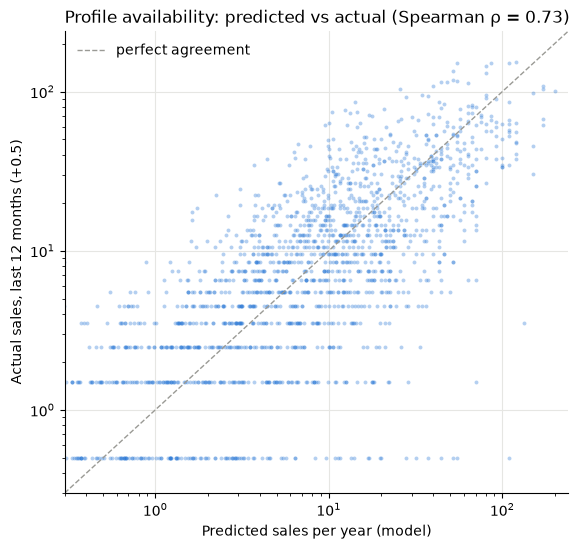

Total predicted sales/yr 27,092 vs actual 24,620


In [13]:
v = profiles.dropna(subset=["wait_months"]).assign(predicted=lambda x: 12 / x["wait_months"])
rho = v[["predicted", "n_last12"]].corr(method="spearman").iloc[0, 1]
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(v["predicted"], v["n_last12"] + 0.5, s=8, alpha=0.35, color="#2a78d6", linewidths=0)
lim = [0.3, max(v["predicted"].max(), v["n_last12"].max()) * 1.2]
ax.plot(lim, lim, color="#9a9a95", linewidth=1, linestyle="--", label="perfect agreement")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Predicted sales per year (model)"); ax.set_ylabel("Actual sales, last 12 months (+0.5)")
ax.set_title(f"Profile availability: predicted vs actual (Spearman ρ = {rho:.2f})", loc="left"); ax.legend(); plt.show()
print(f"Total predicted sales/yr {v['predicted'].sum():,.0f} vs actual {v['n_last12'].sum():,.0f}")

**Finding:** _how well does predicted availability track reality (ρ)? Is the model biased up or down in total?_

In [14]:
out = profiles[["profile_id", "wait_months"]].dropna()
out.to_csv(C.OUTPUTS / "expected_wait.csv", index=False)                      # replaces the placeholder (handover contract)
alloc[["address", "flat_type", "storey_band", "profile_id", "gap_months", "rate", "share"]].to_csv(
    C.PROCESSED / "block_wait_detail.csv", index=False)
print(f"-> outputs/expected_wait.csv: {len(out):,} profiles (replaces the placeholder) · detail -> data/processed/block_wait_detail.csv")

-> outputs/expected_wait.csv: 1,681 profiles (replaces the placeholder) · detail -> data/processed/block_wait_detail.csv
